In [1]:
from matplotlib import pyplot as plt

import json

In [2]:
ARTIFACT_DIR = "../../artifacts/2023-05-S5/experiment-accuracy-layerwise"

In [3]:
def load_data(model_name, layer, basis_name):
    
    filename = f"{ARTIFACT_DIR}/{model_name}/{layer}/{basis_name}/accuracy.json"
    
    with open(filename, 'r') as fh:
        
        return json.load(fh)
    
# load_data("cifar100-resnet18-p1", "layer4", "pca--centered")

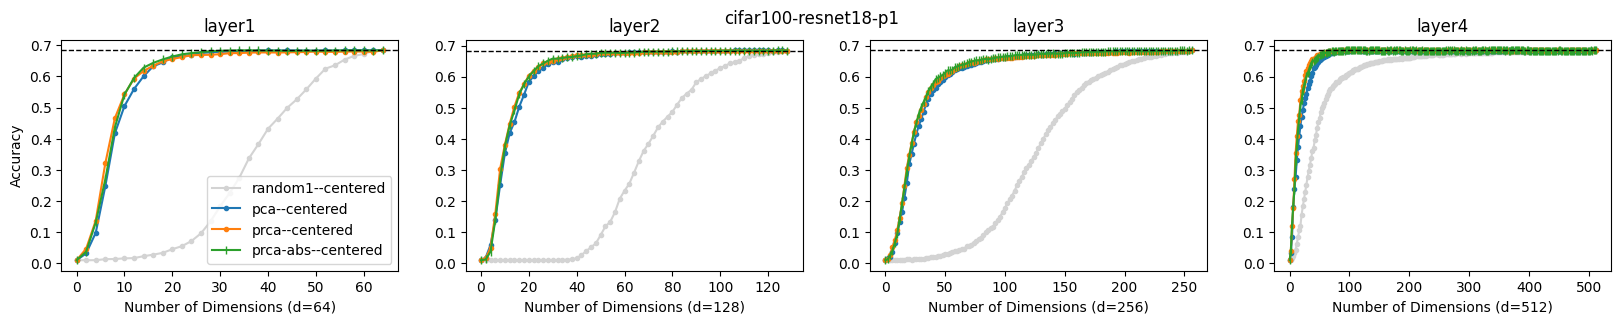

In [18]:
def marker(name):
    
    if "abs" in name:
        return "|"
    elif "recon" in name:
        return "_"
    else:
        return '.'
    
def viz(
    model_name,
    layers=["layer1", "layer2", "layer3", "layer4"],
    basis_names = [
        "random1--centered",
        "pca--centered", "prca--centered", "prca-abs--centered",
#         "prca-recon--centered"
    ],
    divider=1
):
        
    
    ncols = len(layers)
    
    plt.figure(figsize=(5*ncols, 3))
    plt.suptitle(model_name)
    
    orig_acc = None
    
    for lix, layer in enumerate(layers):
        plt.subplot(1, ncols, lix +1)
        plt.title(layer)
        
        for basis_name in basis_names:
        
            data = load_data(model_name, layer, f"{basis_name}")
        
        
            
            ub = len(data["arr_ks"]) // divider
        
            plt.plot(
                data["arr_ks"][:ub], data["accuracies"][:ub], label=basis_name,
                marker=marker(basis_name),
                color="lightgray" if "random" in basis_name else None
            )
        
        
        
        if lix == 0:
            plt.ylabel("Accuracy")
            plt.legend()
        
        dims = data["dims"]
        
        if orig_acc is not None:
            assert data["original_accuracy"] == orig_acc 
            
        orig_acc = data["original_accuracy"]
        
        
        plt.axhline(orig_acc, ls="--", lw=1, color="k")
        
        plt.xlabel(f"Number of Dimensions (d={dims})")
    
viz("cifar100-resnet18-p1")

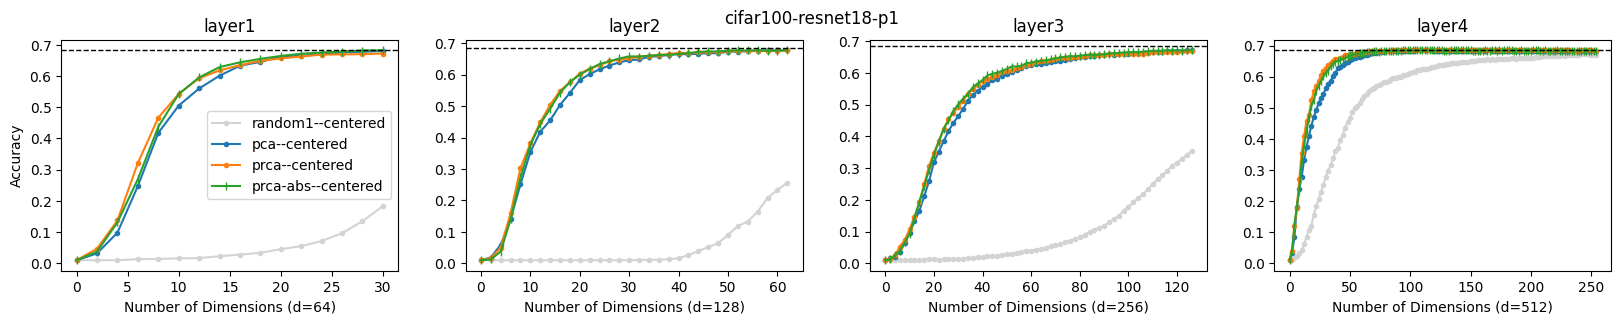

In [19]:
viz("cifar100-resnet18-p1", divider=2)